# Практическое задание №5: Визуализация данных с Matplotlob и Seaborn 
## Выполнил: Мамаев А.

### Цель:
Освоить основные приёмы визуализации данных с использованием библиотек 
Matplotlib и Seaborn. Научиться выбирать подходящий тип графика для разных 
задач анализа, строить и настраивать графики, интерпретировать полученные 
результаты.

### Вариант 4
• Датасет: sns.load_dataset('flights')  
• Задачи: 
1. Построить линейный график динамики пассажиров по годам (среднее за 
год). 
2. Построить тепловую карту: годы по строкам, месяцы по столбцам, значение – количество пассажиров. 
3. Построить столбчатую диаграмму среднего количества пассажиров по 
месяцам. 
4. Построить boxplot распределения пассажиров по годам. 

In [28]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
# Загрузка данных 
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [5]:
# Информация о столбцах и типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [10]:
# Проверка на дубликаты и пропуски
print(f"\nВсего пропусков в датасете: {df.isnull().sum().sum()}")
print(f"Количество дубликатов: {df.duplicated().sum()}")


Всего пропусков в датасете: 0
Количество дубликатов: 0


In [30]:
# Расчет среднего количества пассажиров по годам
yearly_avg = df.groupby('year')['passengers'].mean().reset_index()
print("Среднее количество пассажиров по годам:")
print(yearly_avg)

Среднее количество пассажиров по годам:
    year  passengers
0   1949  126.666667
1   1950  139.666667
2   1951  170.166667
3   1952  197.000000
4   1953  225.000000
5   1954  238.916667
6   1955  284.000000
7   1956  328.250000
8   1957  368.416667
9   1958  381.000000
10  1959  428.333333
11  1960  476.166667


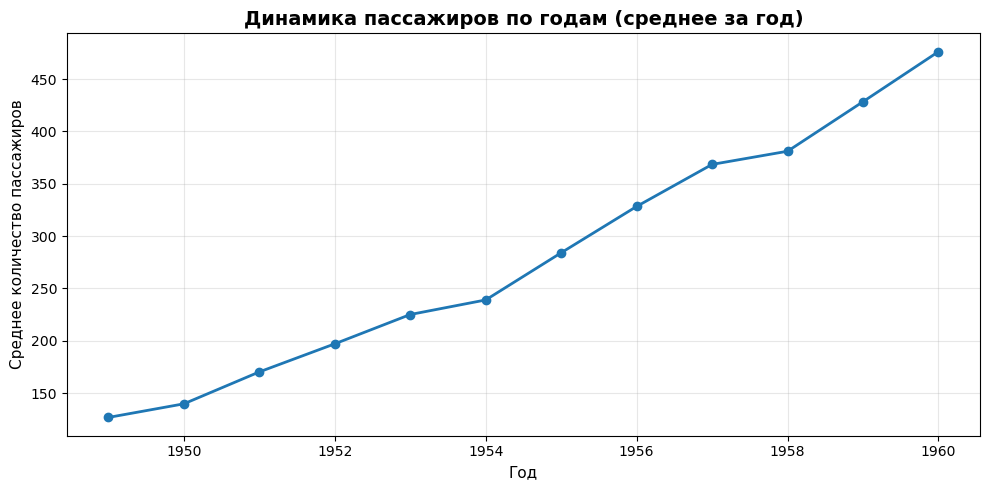

In [31]:
# Построение графика
plt.figure(figsize=(10, 5))
plt.plot(yearly_avg['year'], yearly_avg['passengers'], marker='o', linewidth=2)

# Подписи
plt.title('Динамика пассажиров по годам (среднее за год)', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=11)
plt.ylabel('Среднее количество пассажиров', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Вывод: на графике выше видно, что с каждым годом среднее количество пассажиров увеличивалось. Также стоить отметить, что с 1949 по 1960 годы среднее количество пассажиров увеличилось в 3,75 раза

In [35]:
# Сводная таблица: годы по строкам, месяцы по столбцам
heatmap_data = df.pivot(index='year', columns='month', values='passengers')
print(heatmap_data)

month  Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
year                                                             
1949   112  118  132  129  121  135  148  148  136  119  104  118
1950   115  126  141  135  125  149  170  170  158  133  114  140
1951   145  150  178  163  172  178  199  199  184  162  146  166
1952   171  180  193  181  183  218  230  242  209  191  172  194
1953   196  196  236  235  229  243  264  272  237  211  180  201
1954   204  188  235  227  234  264  302  293  259  229  203  229
1955   242  233  267  269  270  315  364  347  312  274  237  278
1956   284  277  317  313  318  374  413  405  355  306  271  306
1957   315  301  356  348  355  422  465  467  404  347  305  336
1958   340  318  362  348  363  435  491  505  404  359  310  337
1959   360  342  406  396  420  472  548  559  463  407  362  405
1960   417  391  419  461  472  535  622  606  508  461  390  432


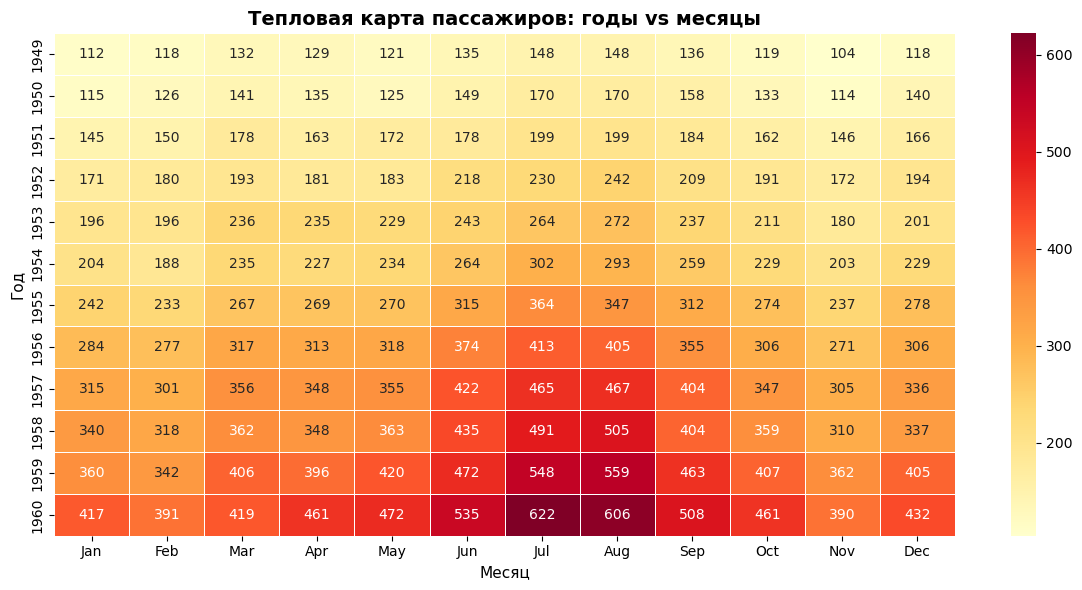

In [37]:
# Построение тепловой карты
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)

# Подписи
plt.title('Тепловая карта пассажиров: годы vs месяцы', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=11)
plt.ylabel('Год', fontsize=11)

plt.tight_layout()
plt.show()

Вывод: на тепловой карте четко прослеживается, что наибольшее количество пассажиров приходится в летние месяцы, а наименьшее в зимний период. Также видно, что с каждым годом общее количество пассажиров увеличивается

In [41]:
# Расчет среднего количества пассажиров по месяцам
monthly_avg = df.groupby('month', observed=False)['passengers'].mean().reset_index()
print(monthly_avg)

   month  passengers
0    Jan  241.750000
1    Feb  235.000000
2    Mar  270.166667
3    Apr  267.083333
4    May  271.833333
5    Jun  311.666667
6    Jul  351.333333
7    Aug  351.083333
8    Sep  302.416667
9    Oct  266.583333
10   Nov  232.833333
11   Dec  261.833333


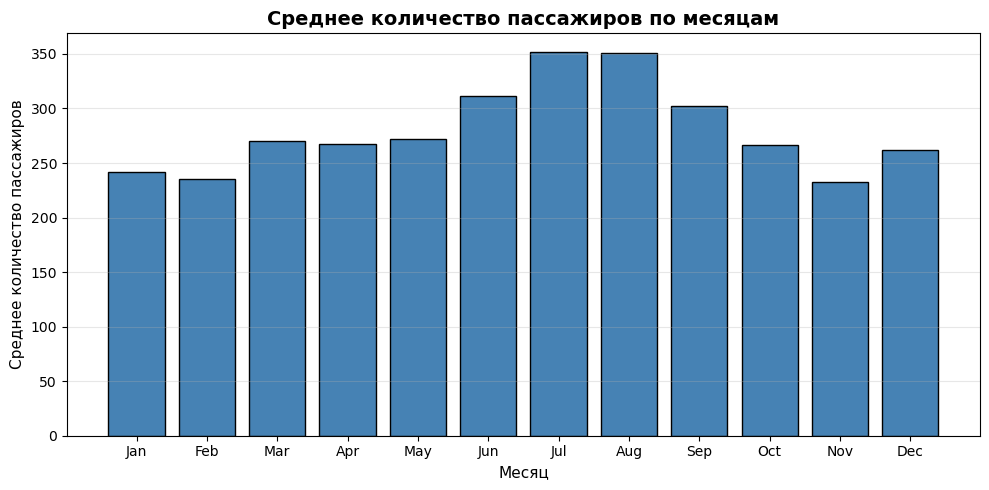

In [42]:
# Построение столбчатой диаграммы
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg['month'], monthly_avg['passengers'], color='steelblue', edgecolor='black')

# Подписи
plt.title('Среднее количество пассажиров по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=11)
plt.ylabel('Среднее количество пассажиров', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Вывод: на графике выше наблюдается ярко выраженная сезонность, летние месяцы (июль-август) имеют наибольшее среднее количество пассажиров, а зимние - наименьшее.

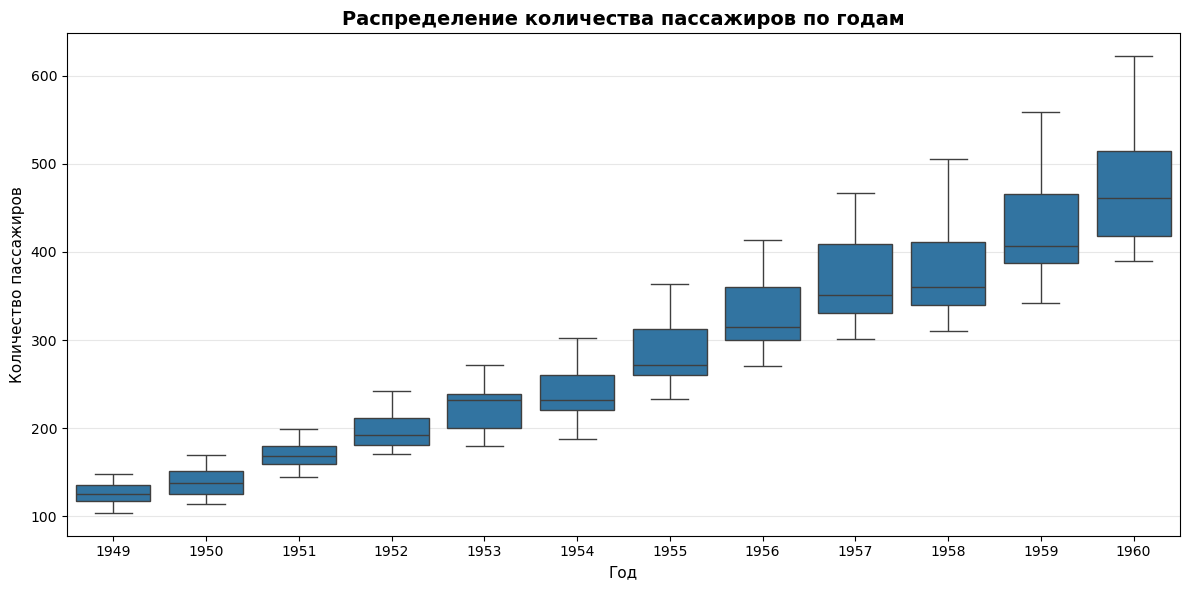

In [43]:
# Построение boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='passengers')

# Подписи
plt.title('Распределение количества пассажиров по годам', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=11)
plt.ylabel('Количество пассажиров', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Вывод: график выше наглядно демонстрирует увеличение медианы и разброса пассажиров от 1949 к 1960 году.

### Общий вывод по датасету:
Датасет демонстрирует пример растущего рынка с ярко выраженной сезонностью. За 12 лет авиаперевозки выросли в 3,75 раза, при этом летние месяцы самые загруженные. Эти данные могут быть использованы для прогнозирования пассажиропотока, планирования ресурсов авиакомпаний и маркетинговых активностей с учетом сезонных колебаний.